# X($\pi$) on the Novera chip — Gaussian vs. Gaussian+DRAG vs. Optimized

Same method as `1qb_Gaussian-drag-optimization_Xpi/` (`_gatelib`, unchanged); only the
*device* moves (`configs/device_novera.json`). See `proposals/Novera_work/README.md`
for the numbers behind every design choice and `_dev_logs/N2_novera_solve.md` for how
arms C–F were solved. This notebook does not re-derive anything `_gatelib` already
documents -- it reads the arms back and reports them.

⚠️ Every cell below reads the device from `al.DEV`, which `armlib.py` bound to
`configs/device_novera.json` -- **never** the package default. The assertion in the
next cell is the guard against the easiest bug to make here.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

_gate_dir = Path.cwd().parent / "gates" / "Novera_Xpi"
assert _gate_dir.exists(), f"run this notebook from Novera_work/notebooks/ (looked for {_gate_dir})"
sys.path.insert(0, str(_gate_dir))
import armlib as al

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.facecolor": "white"})

DEV = al.DEV
assert DEV.anharmonicity == -0.19848, DEV.anharmonicity   # the one bug this project cannot afford

print(f"gate        = {al.spec.name}")
print(f"T           = {al.T:g} ns          M = {DEV.n_modes}   (n* = 2T|alpha| = "
      f"{DEV.resonant_harmonic:.3f}, matched = {DEV.resonant_harmonic_matched})")
print(f"Delta       = {DEV.delta:.6f} rad/ns   ({DEV.anharmonicity*1e3:+.2f} MHz)")
print(f"Omega_max   = {DEV.rabi_max_rate:.6f} rad/ns    eta = Omega_max/|Delta| = {DEV.eta:.4f}")
print(f"design eps  = {DEV.control_error:.1%}      design delta_z = {DEV.static_detuning*1e3:.1f} MHz rms")
print(f"decoh floor = {DEV.decoherence_floor:.4e}   (default-device floor 4.1667e-04, "
      f"{DEV.decoherence_floor / 4.1667e-4:.2f}x higher: t1={DEV.t1:g} ns, t2_echo={DEV.t2_echo:g} ns)")
print(f"AWG export  = {al.N_EXPORT} samples @ {DEV.sample_rate} GS/s")
print(f"fluence unit F0 = theta^2/T = {al.FLUENCE_FLOOR:.5f} rad^2/ns")

<string>:12: UserWarning: leakage-resonant harmonic n* = 2*T*|alpha| = 19.848 != n_modes = 20: the C4 spectral zero no longer lands on a basis harmonic (device.GROUPS, _plan_full_cost.md 2.6). This is allowed -- it is a design choice, not an error -- but any C4 claim from this device needs the mismatch stated.


gate        = X(pi) [Novera]
T           = 50 ns          M = 20   (n* = 2T|alpha| = 19.848, matched = False)
Delta       = -1.247087 rad/ns   (-198.48 MHz)
Omega_max   = 0.314159 rad/ns    eta = Omega_max/|Delta| = 0.2519
design eps  = 2.0%      design delta_z = 0.1 MHz rms
decoh floor = 6.3587e-04   (default-device floor 4.1667e-04, 1.53x higher: t1=35000 ns, t2_echo=41900 ns)
AWG export  = 120 samples @ 2.4 GS/s
fluence unit F0 = theta^2/T = 0.19739 rad^2/ns


## 1. Arms

In [2]:
arms = al.build_arms()
for k in al.ARM_ORDER:
    a = arms[k]
    print(f"{k}  {a.name:20s} layer={a.layer:12s} run_id={getattr(a, 'run_id', None)}")

A  Gaussian             layer=planar       run_id=None
B  Gaussian + DRAG      layer=planar_drag  run_id=None
C  Optimized (3D)       layer=general      run_id=20260809_Xpi_novera_armC_accepted
D  Opt + fluence cap    layer=general      run_id=20260809_Xpi_novera_armD_accepted
E  Opt AD-exact         layer=general      run_id=20260809_Xpi_novera_armE_accepted
F  Opt AD-robust        layer=general      run_id=20260809_Xpi_novera_armF_accepted


## Fig. 1 — played waveforms (120-pt AWG grid), $\pm\Omega_{\max}$ ceiling

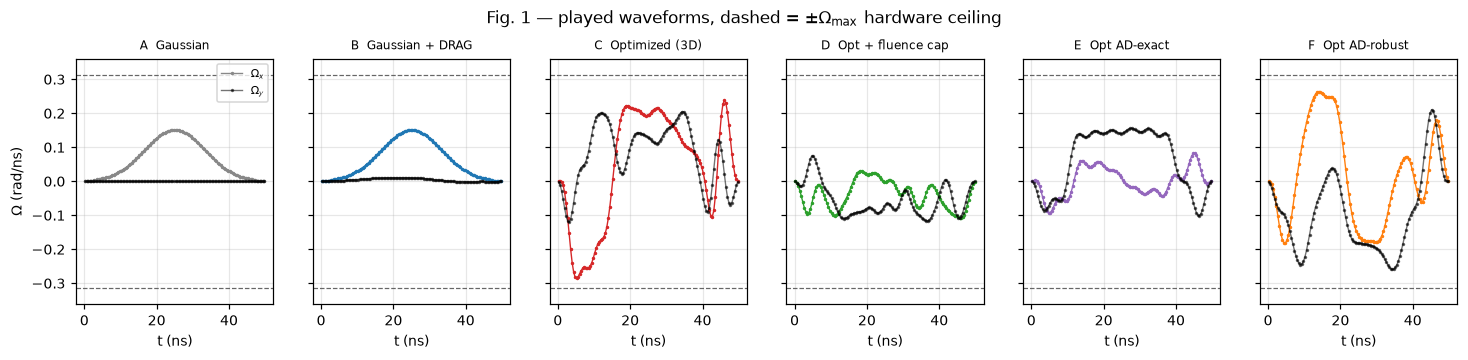

In [3]:
from curve_opt import geometry

t_awg, _ = geometry.midpoint_grid(al.T, al.N_EXPORT)

fig, axes = plt.subplots(1, len(al.ARM_ORDER), figsize=(2.7 * len(al.ARM_ORDER), 2.9),
                         sharex=True, sharey=True)
for ax, k in zip(axes, al.ARM_ORDER):
    ox, oy = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, ".-", ms=2.5, lw=0.9, color=al.ARM_COLORS[k], label=r"$\Omega_x$")
    ax.plot(t_awg, oy, ".-", ms=2.5, lw=0.9, color="k", alpha=0.55, label=r"$\Omega_y$")
    for s in (+1, -1):
        ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=8)
    ax.set_xlabel("t (ns)")
ax.set_ylim(-1.15 * DEV.rabi_max_rate, 1.15 * DEV.rabi_max_rate)
axes[0].set_ylabel(r"$\Omega$ (rad/ns)")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle(r"Fig. 1 — played waveforms, dashed = $\pm\Omega_{\max}$ hardware ceiling", y=1.03)
plt.show()

## 2. Table 1 — the noiseless comparison

★ **C3 is a diagnostic here, not a claim.** `propagate.tantrix_area` uses the bare-$\Omega$
form, which is not the tantrix area once $\tau \neq 0$, so every 3D arm's C3 below is known
to be biased (README §8). Arm F's objective (`ad_robust`) does not depend on C3, so this
does not affect the deliverable -- the fix is tracked separately as F09d.

In [4]:
rows = {k: al.characterize(arms[k]) for k in al.ARM_ORDER}

# sampling loss: what the N_EXPORT=120 AWG grid costs relative to the N_DESIGN continuum
# the design was solved on -- computed the same way gatelib.export_arms reports it.
from curve_opt import qutip_sim
sampling_loss = {}
for k in al.ARM_ORDER:
    ox120, oy120 = al.broadcast_of(arms[k], al.N_EXPORT)
    infid_120, _phi, _ = qutip_sim.coherent_infidelity(t_awg, ox120, oy120, al.T, DEV.delta, al.U_TARGET)
    sampling_loss[k] = float(infid_120) / rows[k]["baseline_infidelity"]

tab = pd.DataFrame({
    "arm": [f"{k} {arms[k].name}" for k in al.ARM_ORDER],
    "C1": [rows[k]["c1"] for k in al.ARM_ORDER],
    "C2": [rows[k]["c2"] for k in al.ARM_ORDER],
    "C3 (diag.)": [rows[k]["c3"] for k in al.ARM_ORDER],
    "C4": [rows[k]["c4"] for k in al.ARM_ORDER],
    "1-Fbar (0 noise)": [rows[k]["baseline_infidelity"] for k in al.ARM_ORDER],
    "leakage": [rows[k]["leakage_population"] for k in al.ARM_ORDER],
    "fluence/F0": [rows[k]["fluence_over_floor"] for k in al.ARM_ORDER],
    "peak/Omega_max": [rows[k]["peak_frac"] for k in al.ARM_ORDER],
    "Phi_vz": [rows[k]["phi_vz"] for k in al.ARM_ORDER],
    "sampling loss (120pt/fine)": [sampling_loss[k] for k in al.ARM_ORDER],
    "decoh floor": [rows[k]["decoherence_floor"] for k in al.ARM_ORDER],
    "total (coherent+decoh)": [rows[k]["true_plus_decoh"] for k in al.ARM_ORDER],
}).set_index("arm")

fmt = {c: "{:.4e}".format for c in tab.columns}
fmt["peak/Omega_max"] = "{:.1%}".format
fmt["fluence/F0"] = "{:.3f}".format
fmt["Phi_vz"] = "{:+.5f}".format
fmt["sampling loss (120pt/fine)"] = "{:.4f}".format
tab_show = pd.DataFrame({c: [fmt[c](v) for v in tab[c]] for c in tab.columns}, index=tab.index)
print("Table 1 - noiseless (delta_z = epsilon = 0), Novera device")
display(tab_show)

Table 1 - noiseless (delta_z = epsilon = 0), Novera device


,C1,C2,C3 (diag.),C4,1-Fbar (0 noise),leakage,fluence/F0,peak/Omega_max,Phi_vz,sampling loss (120pt/fine),decoh floor,total (coherent+decoh)
arm,,,,,,,,,,,,
A Gaussian,1.9555e-05,7.5028e-09,6.5797e-04,7.3410e-06,1.7455e-03,1.0314e-05,1.712,48.2%,+0.00000,1.0000,6.3587e-04,2.3813e-03
B Gaussian + DRAG,1.9555e-05,7.5028e-09,6.5797e-04,3.1981e-09,7.4549e-06,4.3654e-09,1.712,48.2%,+0.13548,0.9997,6.3587e-04,6.4332e-04
C Optimized (3D),6.0279e-09,1.8128e-10,1.2660e-09,1.5343e-09,6.5676e-05,9.8503e-05,10.452,91.0%,-0.13465,0.9555,6.3587e-04,7.0154e-04
D Opt + fluence cap,5.5478e-05,1.0634e-08,4.2167e-04,2.6897e-07,4.4537e-06,6.6798e-06,1.996,48.5%,+2.53425,0.9600,6.3587e-04,6.4032e-04
E Opt AD-exact,5.3384e-06,3.2219e-09,6.1696e-04,4.7615e-06,3.0575e-08,4.5822e-08,3.508,50.6%,+3.03086,0.9057,6.3587e-04,6.3590e-04
F Opt AD-robust,5.2374e-06,1.1057e-09,5.9131e-04,4.9109e-05,2.6270e-06,9.7659e-07,10.634,85.6%,-2.61787,0.3109,6.3587e-04,6.3849e-04


## 3. Noise sweep — Fig. 2 (7×7 heatmap) and Fig. 3 (1-D $\epsilon$ slice)

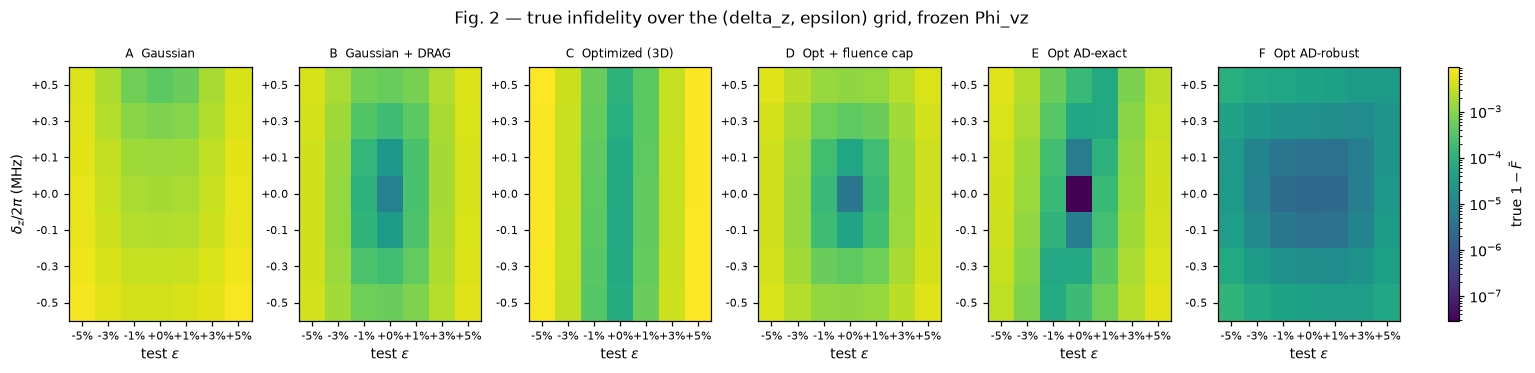

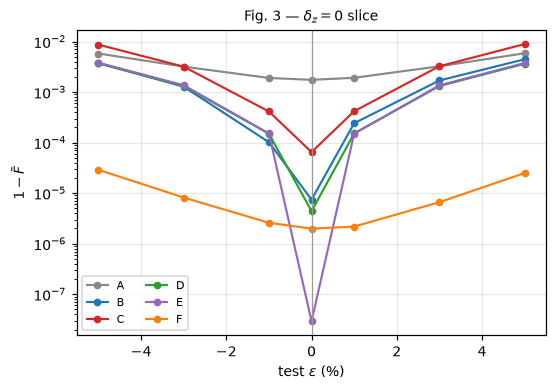

In [5]:
sweeps = {k: al.sweep(arms[k], rows[k]["phi_vz"]) for k in al.ARM_ORDER}

vmin = min(s.min() for s in sweeps.values())
vmax = max(s.max() for s in sweeps.values())
ext = [-0.5, len(al.EPS_GRID) - 0.5, -0.5, len(al.DELTA_MHZ_GRID) - 0.5]

def _noise_ticks(ax):
    ax.set_xticks(range(len(al.EPS_GRID)), [f"{e:+.0%}" for e in al.EPS_GRID], fontsize=7)
    ax.set_yticks(range(len(al.DELTA_MHZ_GRID)), [f"{d:+.1f}" for d in al.DELTA_MHZ_GRID], fontsize=7)
    ax.set_xlabel(r"test $\epsilon$")
    ax.grid(False)

n_arms = len(al.ARM_ORDER)
fig = plt.figure(figsize=(2.6 * n_arms + 0.7, 3.0))
gs = fig.add_gridspec(1, n_arms + 1, width_ratios=[1] * n_arms + [0.06], wspace=0.30)
for i, k in enumerate(al.ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(sweeps[k], origin="lower", aspect="auto", extent=ext,
                   norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=8)
    _noise_ticks(ax)
    if i == 0:
        ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
fig.colorbar(im, cax=fig.add_subplot(gs[0, n_arms]), label=r"true $1-\bar F$")
fig.suptitle("Fig. 2 — true infidelity over the (delta_z, epsilon) grid, frozen Phi_vz", y=1.05)
plt.show()

i0 = int(np.where(al.DELTA_MHZ_GRID == 0.0)[0][0])
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for k in al.ARM_ORDER:
    ax.semilogy(al.EPS_GRID * 100, sweeps[k][i0], "o-", color=al.ARM_COLORS[k], lw=1.4, ms=4, label=k)
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel(r"test $\epsilon$ (%)"); ax.set_ylabel(r"$1-\bar F$")
ax.set_title(r"Fig. 3 — $\delta_z=0$ slice", fontsize=9)
ax.legend(fontsize=7, ncol=2)
plt.show()

## 4. Winner — both criteria (README §7 point 4)

In [6]:
RATIO_ARMS = tuple(k for k in al.ARM_ORDER if k not in ("A", "B"))
wins = {k: int(np.sum(sweeps[k] < sweeps["B"])) for k in RATIO_ARMS}
total_pts = sweeps["B"].size

best_zero_noise = min(al.ARM_ORDER, key=lambda k: rows[k]["baseline_infidelity"])
best_grid = max(RATIO_ARMS, key=lambda k: wins[k])

print("criterion 1 -- lowest zero-noise coherent 1-Fbar:")
for k in al.ARM_ORDER:
    print(f"  {k}: {rows[k]['baseline_infidelity']:.4e}"
          f"{'   <-- best' if k == best_zero_noise else ''}")
print(f"\ncriterion 2 -- grid points beating arm B ({total_pts} total, (delta_z, epsilon) design grid):")
for k in RATIO_ARMS:
    print(f"  {k}: {wins[k]}/{total_pts}{'   <-- best' if k == best_grid else ''}")

print(f"\nBoth criteria reported, neither overridden: criterion 1 picks {best_zero_noise} "
      f"({rows[best_zero_noise]['baseline_infidelity']:.3e}), criterion 2 picks {best_grid} "
      f"({wins[best_grid]}/{total_pts}). If they disagree that is the finding, not a tie to break "
      f"here (README §7 point 4: 'the winner is whatever the runs say').")


criterion 1 -- lowest zero-noise coherent 1-Fbar:
  A: 1.7455e-03
  B: 7.4549e-06
  C: 6.5676e-05
  D: 4.4537e-06
  E: 3.0575e-08   <-- best
  F: 2.6270e-06

criterion 2 -- grid points beating arm B (49 total, (delta_z, epsilon) design grid):
  C: 8/49
  D: 19/49
  E: 37/49
  F: 49/49   <-- best

Both criteria reported, neither overridden: criterion 1 picks E (3.058e-08), criterion 2 picks F (49/49). If they disagree that is the finding, not a tie to break here (README §7 point 4: 'the winner is whatever the runs say').


## 5. Export (README §6)

In [7]:
manifest = al.export_arms(arms, rows)
print(json.dumps(manifest["arms"], indent=1))
print("\nfiles:")
for p in sorted((al.folder / "waveforms").iterdir()):
    print(f"  {p.relative_to(al.folder)}  ({p.stat().st_size} bytes)")

print("\nPhi_vz shipped in each exported arm JSON (must match the phi_vz column in Table 1):")
for k in al.ARM_ORDER:
    j = json.loads((al.folder / "waveforms" / f"{al.SLUGS[k]}.json").read_text())
    table_phi = rows[k]["phi_vz"]
    exported_phi = j["phi_vz"]
    exported_status = j["status"]
    print(f"  {k}: table={table_phi:.10f}  exported_json={exported_phi:.10f}  status={exported_status!r}")


{
 "A": {
  "name": "Gaussian",
  "layer": "planar",
  "csv": "waveforms/A_gaussian_120pt.csv",
  "json": "waveforms/A_gaussian.json",
  "run_id": null,
  "status": null,
  "infidelity_120pt": 0.0017454580350159121,
  "infidelity_fine": 0.0017454591862660074,
  "sampling_loss_ratio": 0.9999993404313866
 },
 "B": {
  "name": "Gaussian + DRAG",
  "layer": "planar_drag",
  "csv": "waveforms/B_gaussian_drag_120pt.csv",
  "json": "waveforms/B_gaussian_drag.json",
  "run_id": null,
  "status": null,
  "infidelity_120pt": 7.452874514091157e-06,
  "infidelity_fine": 7.454934296546867e-06,
  "sampling_loss_ratio": 0.9997237021315313
 },
 "C": {
  "name": "Optimized (3D)",
  "layer": "general",
  "csv": "waveforms/C_optimized_120pt.csv",
  "json": "waveforms/C_optimized.json",
  "run_id": "20260809_Xpi_novera_armC_accepted",
  "status": "maxiter",
  "infidelity_120pt": 6.275472274275273e-05,
  "infidelity_fine": 6.567624176956333e-05,
  "sampling_loss_ratio": 0.9555163488638516
 },
 "D": {
  "na

## What the run says

Filled in from the numbers above:

* Table 1 -- the coherent zero-noise ranking and where the fluence/peak budget went
  (arm F sits closest to its hard constraints -- see `_dev_logs/N2_novera_solve.md`,
  "arm F 的边界状态").
* Fig. 2/3 -- how each arm's error grows with $\epsilon$ and $\delta_z$ away from the
  design point.
* Section 4 -- the two winner criteria, reported side by side rather than collapsed
  into one number.